# Credit Card Fraud Detection with Decision Trees and SVM

## Import Libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight

%matplotlib inline

## Load the dataset

<p>Execute the cell below to load the dataset to the variable <code>raw_data</code>. The code will fetch the dataset for the URL and load the same to the variable. A snapshot of the dataset will be generated as an output.</p>

In [2]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/creditcard.csv"

# file too large to upload to GitHub
raw_data = pd.read_csv(url)
raw_data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


## Dataset Analysis

<p>Each row in the dataset represents a credit card transaction. As shown above, each row has 31 variables. One variable (the last variable in the table above) is called Class and represents the target variable. Your objective will be to train a model that uses the other variables to predict the value of the Class variable. Let's first retrieve basic statistics about the target variable.</p>
<p>Note: For confidentiality reasons, the original names of most features are anonymized <code>V1</code>, <code>V2</code>, ..., <code>V28</code>. The values of these features are the result of a PCA transformation and are numerical. The feature <code>Class</code> is the target variable and it takes two values: <code>1</code> in case of fraud and <code>0</code> otherwise. For more information about the dataset please visit this <a href="https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud">webpage</a>.</p>

Text(0.5, 1.0, 'Target Variable Value Counts')

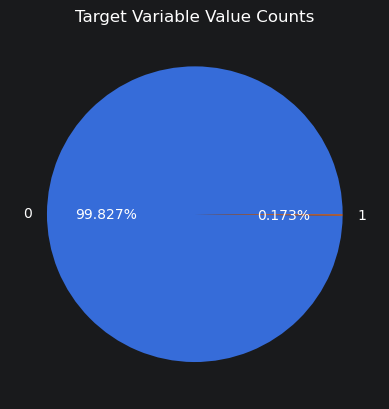

In [3]:
labels = raw_data.Class.unique()
sizes = raw_data.Class.value_counts().values

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct="%1.3f%%")
ax.set_title("Target Variable Value Counts")

<p>As shown above, the <code>Class</code> variable has two values: <code>0</code> (the credit card transaction is legitimate) and <code>1</code> (the credit card transaction is fraudulent). Thus, you need to model a binary classification problem. Moreover, the dataset is highly unbalanced, the target variable classes are not represented equally. This case requires special attention when training or when evaluating the quality of a model. One way of handing this case at train time is to bias the model to pay more attention to the samples in the minority class. The models under the current study will be configured to take into account the class weights of the samples at train/fit time.</p>
<p>It is also prudent to understand which features affect the model in what way. We can visualize the effect of the different features on the model using the code below.</p>

<Axes: >

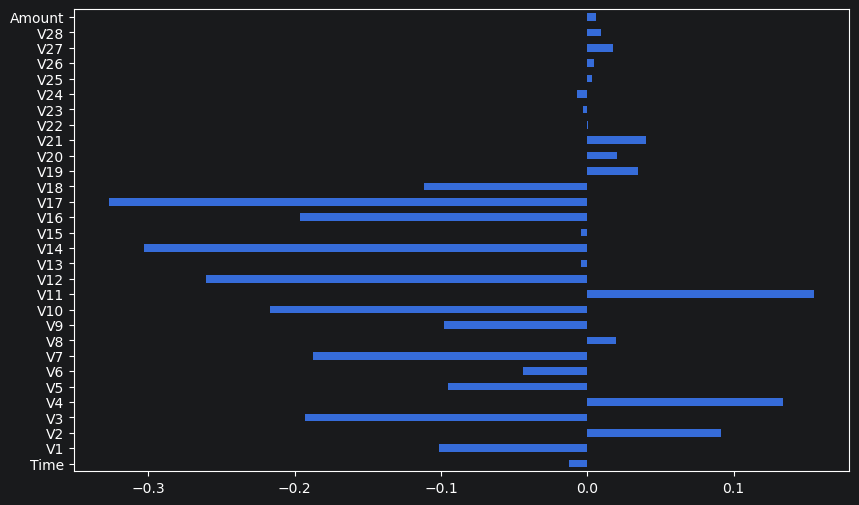

In [4]:
correlation_values = raw_data.corr()["Class"].drop("Class")
correlation_values.plot(kind="barh", figsize=(10, 6))

<p>This clearly shows that some features affect the output <code>Class</code> more than the others. For efficient modeling, we may use only the most correlated features.</p>

## Dataset Preprocessing

<p>You will now prepare the data for training. You will apply standard scaling to the input features and normalize them using $L_1$ norm for the training models to converge quickly. As seen in the data snapshot, there is a parameter called <code>Time</code> which we will not be considering for modeling. Hence, features <code>2</code> to <code>30</code> will be used as input features and feature <code>31</code>, i.e. <code>Class</code> will be used as the target variable.</p>

In [5]:
raw_data.iloc[:, 1:30] = StandardScaler().fit_transform(raw_data.iloc[:, 1:30])
data_matrix = raw_data.values

X = data_matrix[:, 1:30]
y = data_matrix[:, 30]
X = normalize(X, norm="l1")

## Dataset Train/Test Split

<p>Now that the dataset is ready for building the classification models, you need to first divide the preprocessed dataset into a subset to be used for training the model (the train set) and a subset to be used for evaluating the quality of the model (the test set).</p>

In [6]:
split_data: list[np.ndarray] = train_test_split(X, y, test_size=0.3, random_state=42)
X_train, X_test, y_train, y_test = split_data

## Build a Decision Tree Classifier model with `scikit-learn`

<p>Compute the sample weights to be used as input to the train routine so that it takes into account the class imbalance present in this dataset.</p>

In [7]:
w_train = compute_sample_weight("balanced", y_train)

<p>Using these sample weights, we may train the Decision Tree classifier. We also make note of the time it takes for training this model to compare it against SVM, later in the lab.</p>

In [8]:
dt = DecisionTreeClassifier(max_depth=4, random_state=35)
dt.fit(X_train, y_train, sample_weight=w_train)

DecisionTreeClassifier(max_depth=4, random_state=35)

## Build a Support Vector Machine model with `scikit-learn`

<p>Unlike Decision Trees, we do not need to initiate a separate sample weight for SVMs. We can simply pass a parameter in the <code>scikit-learn</code> function.</p>

In [9]:
svm = LinearSVC(class_weight="balanced", random_state=31, loss="hinge", fit_intercept=False)
svm.fit(X_train, y_train)

LinearSVC(class_weight='balanced', fit_intercept=False, loss='hinge',
          random_state=31)

## Evaluate the Decision Tree Classifier Models

<p>Run the following cell to compute the probabilities of the test samples belonging to the class of fraudulent transactions.</p>

In [10]:
y_pred_dt = dt.predict_proba(X_test)[:, 1]

<p>Using these probabilities, we can evaluate the Area Under the Receiver Operating Characteristic Curve (ROC-AUC) score as a metric of model performance. The ROC-AUC score evaluates your model's ability to distinguish positive and negative classes considering all possible probability thresholds. The higher its value, the better the model is considered for separating the two classes of values.</p>

In [11]:
roc_auc_dt = roc_auc_score(y_test, y_pred_dt)
f"Decision Tree ROC-AUC score: {roc_auc_dt:.3f}"

'Decision Tree ROC-AUC score: 0.939'

## Evaluate the Support Vector Machine Models

<p>Run the following cell to compute the probabilities of the test samples belonging to the class of fraudulent transactions.</p>

In [12]:
y_pred_svm = svm.decision_function(X_test)

<p>You may now evaluate the accuracy of SVM on the test set in terms of the ROC-AUC score.</p>

In [13]:
roc_auc_svm = roc_auc_score(y_test, y_pred_svm)
f"SVM ROC-AUC score: {roc_auc_svm:.3f}"

'SVM ROC-AUC score: 0.986'

## Practice Exercises

<p>1. Currently, we have used all 30 features of the dataset for training the models. Use the <code>corr()</code> function to find the top 6 features of the dataset to train the models on.</p>

In [14]:
correlation_values = abs(raw_data.corr()["Class"]).drop("Class")
correlation_values = correlation_values.sort_values(ascending=False)[: 6]
correlation_values

V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
Name: Class, dtype: float64

<p>2. Using only this 6 features, modify the input variable for training.</p>

In [15]:
data_matrix[:, [3, 10, 12, 14, 16, 17]]

array([[ 1.6727735 ,  0.08338555, -0.61829572, -0.32461019, -0.53683287,
         0.24486345],
       [ 0.1097971 , -0.15334963,  1.06608857, -0.14998248,  0.52943375,
        -0.13516997],
       [ 1.16946849,  0.19069961,  0.06613662, -0.17311389, -3.29823537,
         1.30686788],
       ...,
       [-2.14320514, -0.44522451,  0.06316942, -0.53265708,  0.1605886 ,
         0.36911416],
       [ 0.46332013, -0.36655778, -0.96365742,  0.46904579, -0.69452347,
         0.60038514],
       [ 0.46386564, -0.84072963, -0.0315383 , -0.08795849, -0.34535763,
        -0.77752147]], shape=(284807, 6))

****
This is the end of the file.
****